<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/classification_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [1]:
!pip install plotly
!pip install missingno
!pip install scikit-learn
!pip install tabulate
!pip install pandas openpyxl

In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Importing Data**

In [3]:
# Reading data
#https://github.com/kwanda2426/projects/blob/df48e82bc9bfe63d3772e6681c3e0ed3d395c57b/Heart_Attack.xlsx
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/Heart_Attack.xlsx"

In [4]:
df = pd.read_excel(url, header=None)

# Assuming all data is in the first column
df_test = df[0].str.split(",", expand=True)
df_test.columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

#final df
df = df_test.drop(index=0).reset_index(drop=True)

In [5]:
# Showing first 5 lines of data
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
#data columns
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following columns:')
for i in df.columns:
  print(i)

Data has 303 rows and 14 Columns

Data has the following columns:
age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal
target


### Data Type of Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       303 non-null    object
 1   sex       303 non-null    object
 2   cp        303 non-null    object
 3   trestbps  303 non-null    object
 4   chol      303 non-null    object
 5   fbs       303 non-null    object
 6   restecg   303 non-null    object
 7   thalach   303 non-null    object
 8   exang     303 non-null    object
 9   oldpeak   303 non-null    object
 10  slope     303 non-null    object
 11  ca        303 non-null    object
 12  thal      303 non-null    object
 13  target    303 non-null    object
dtypes: object(14)
memory usage: 33.3+ KB


Data set has no missing values. We need to be convert these features into numeric all.

In [9]:
df = df.apply(pd.to_numeric, errors='coerce')

## Describing the variables

In [10]:
#describing numerical columns
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
# Create the data as a list of dictionaries
variables = [
    {"variable": "age", "description": "Age of the individual."},
    {"variable": "sex", "description": "Gender of the individual (1 = male; 0 = female)."},
    {"variable": "cp", "description": "Chest pain type: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic."},
    {"variable": "trestbps", "description": "Resting blood pressure in mmHg, upon admission to the hospital."},
    {"variable": "chol", "description": "Serum cholesterol level in mg/dL."},
    {"variable": "fbs", "description": "Fasting blood sugar > 120 mg/dL (1 = true; 0 = false)."},
    {"variable": "restecg", "description": "Resting ECG results: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy by Estes' criteria."},
    {"variable": "thalach", "description": "Maximum heart rate achieved during strenuous exercise."},
    {"variable": "exang", "description": "Exercise-induced angina (1 = yes; 0 = no)."},
    {"variable": "oldpeak", "description": "ST depression induced by exercise relative to rest (in mm)."},
    {"variable": "slope", "description": "Slope of peak exercise ST segment: 0 = Upsloping, 1 = Flat, 2 = Downsloping."},
    {"variable": "ca", "description": "Number of major vessels (0–3) colored by fluoroscopy."},
    {"variable": "thal", "description": "Thalassemia blood disorder indicator."}
]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(var_desc, headers='keys', tablefmt='pretty'))


+----+----------+------------------------------------------------------------------------------------------------------------------+
|    | variable |                                                   description                                                    |
+----+----------+------------------------------------------------------------------------------------------------------------------+
| 0  |   age    |                                              Age of the individual.                                              |
| 1  |   sex    |                                 Gender of the individual (1 = male; 0 = female).                                 |
| 2  |    cp    |        Chest pain type: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic.         |
| 3  | trestbps |                         Resting blood pressure in mmHg, upon admission to the hospital.                          |
| 4  |   chol   |                                        Serum choles

The categorical variables will need to be encoded if they will be used in building the model.

- Age and sex are foundational factors, as older individuals and males tend to have a higher likelihood of developing heart disease.
- Chest pain type (cp) is a critical symptom indicator, with typical angina being most strongly associated with coronary artery disease.
- Resting blood pressure (trestbps)
- serum cholesterol (chol) are key markers of hypertension and lipid imbalance, both major contributors to atherosclerosis.
- Fasting blood sugar (fbs) levels above 120 mg/dL suggest diabetes, which significantly elevates heart risk.
- Resting electrocardiogram results (restecg) can reveal abnormalities such as ST-T wave changes or left ventricular hypertrophy, indicating underlying cardiac dysfunction.
- Maximum heart rate achieved during exercise (thalach) reflects cardiovascular fitness.
- Exercise-induced angina (exang)
- ST depression during exercise (oldpeak) are direct signs of ischemia.
- The slope of the ST segment (slope), whether upsloping, flat, or downsloping, provides further insight into heart stress response.
- The number of major vessels colored by fluoroscopy (ca) indicates the extent of arterial blockage.
- Thalassemia status (thal), though primarily a blood disorder, can influence oxygen transport and cardiac strain.

# **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

## **Correlation**
This is meant to discover :
- Relationship between features and target variable.
- Multicollinearity - where features are highly correlated to each other. This guides whether to combine features or not as this means that features carry the same information.
- Most informative features. This helps to (simplify the model, reduce noise and improve predictive accuracy) by focusing on informative features only.
- Patterns such as if one feature increases, so does another OR One decreases , the other increases.
- +1 shows a strong positive correlation and -1 shows a strong negative correlation.


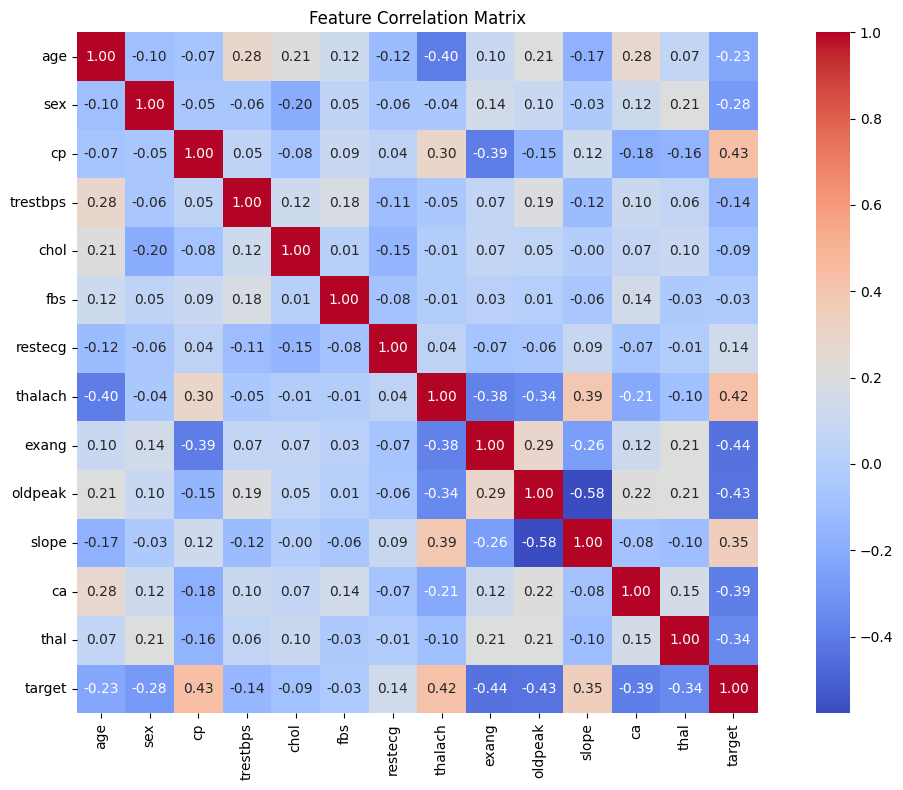

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
df_1 = df.copy()
correlation_matrix = df_1.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

- There's a positive strong correlation between age and cholesterol. This means that as the age increases so do the cholesterol levels.
- There's a strong correlation between chest pains and target(disease). This means that chest pains are some indicators of heart disease.
- Positive correlation between chest pains and maximum heart rate. This makes sense When people experience chest pain, especially during physical effort, their heart rate often goes up. This is because the body reacts to discomfort or stress by speeding up the heartbeat. In many cases, both chest pain and a high heart rate happen together—especially during tests or exercise—so they appear linked in the data. That's why you might see a positive correlation between chest pain and maximum heart rate: they tend to rise at the same time, even if one doesn't directly cause the other.
- Heart Rate and Target(disease) have a positive correlation. Studies show that elevated heart rate—especially during physical exertion—can be a meaningful signal in identifying heart disease. People with heart conditions often reach higher heart rates under stress, and this response is linked to how their cardiovascular system copes with demand. In fact, elevated heart rate has been recognized as an independent risk factor for heart disease and even mortality, regardless of other conditions like high blood pressure or cholesterol




## **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

###**Gender(sex) Distribution**

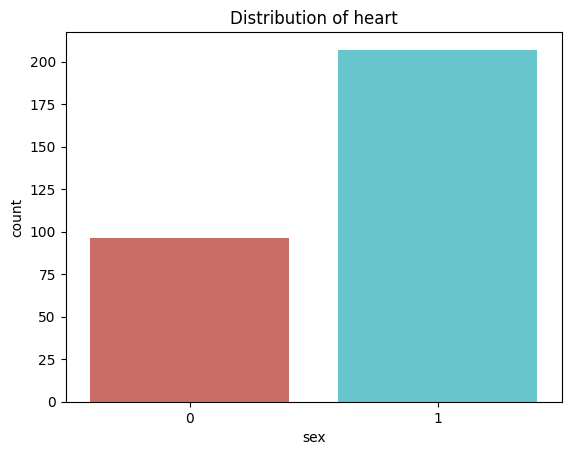

In [13]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'sex', data = df_1, palette = "hls")
plt.title("Distribution of heart");

These two groups are not equal represented. Males are more than females.

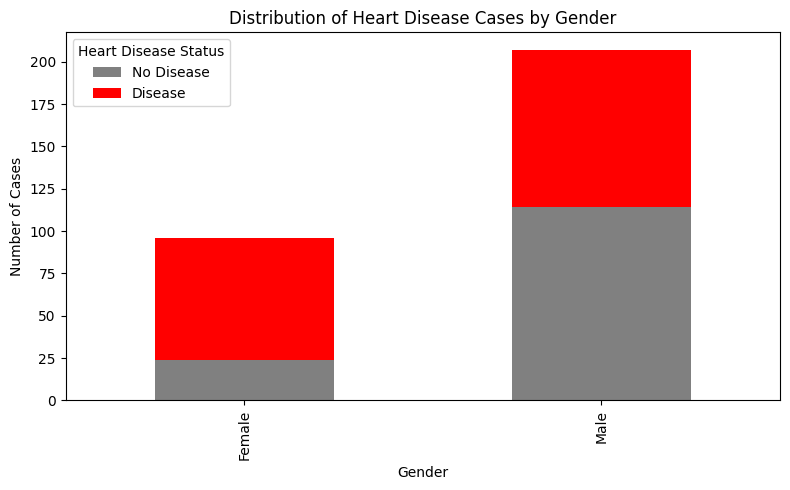

In [14]:
gender_df = df.groupby(['sex', 'target']).size().unstack()

# Rename index for clarity
gender_df.index = ['Female', 'Male']
gender_df.columns = ['No Disease', 'Disease']

# Plot
gender_df.plot(kind='bar', stacked=True, figsize=(8, 5), color=['grey', 'red'])
plt.title('Distribution of Heart Disease Cases by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Cases')
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.show()

We see more cases of disease in females and more no disease in males. This could be that the data collected among females showed more cases.

###**Resting Electrocardiogram Results**

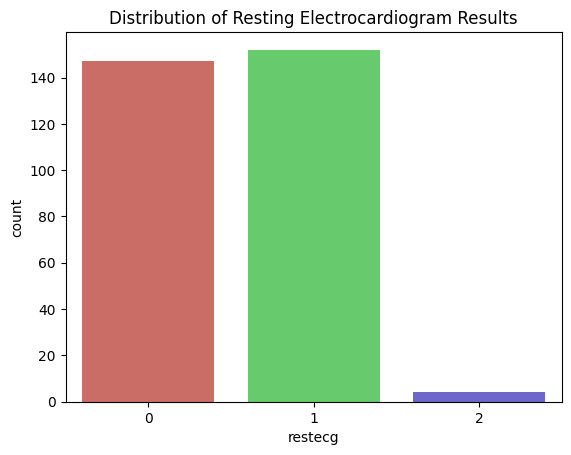

In [15]:
df_1 = df.copy()
sns.countplot(x = 'restecg', data = df_1, palette = "hls")
plt.title("Distribution of Resting Electrocardiogram Results");

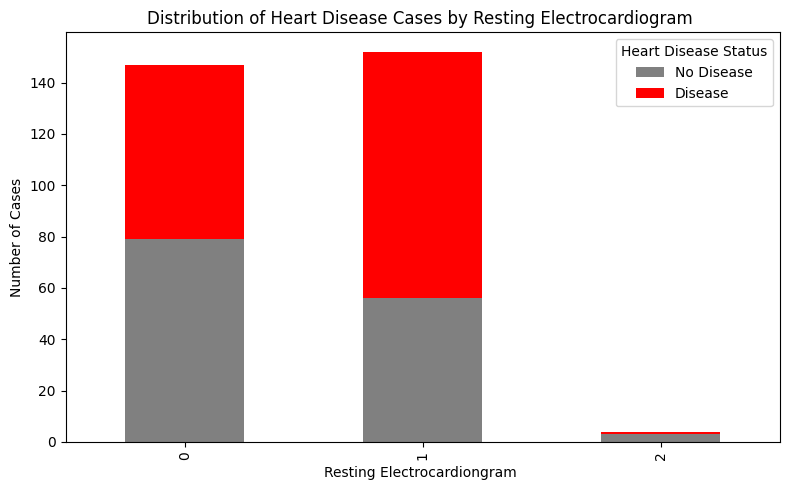

In [16]:
#countplot of Resting Electrocardiongram
Resting_cad_df = df.groupby(['restecg', 'target']).size().unstack()

# Rename index for clarity
Resting_cad_df.index = ['0','1', '2']
Resting_cad_df.columns = ['No Disease', 'Disease']

# Plot
Resting_cad_df.plot(kind='bar', stacked=True, figsize=(8, 5), color=['grey', 'red'])
plt.title('Distribution of Heart Disease Cases by Resting Electrocardiogram ')
plt.xlabel('Resting Electrocardiongram ')
plt.ylabel('Number of Cases')
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.show()

Looks like no disease is on 2 and 0, but 1 has more cases of disease.

###**Age Distribution**

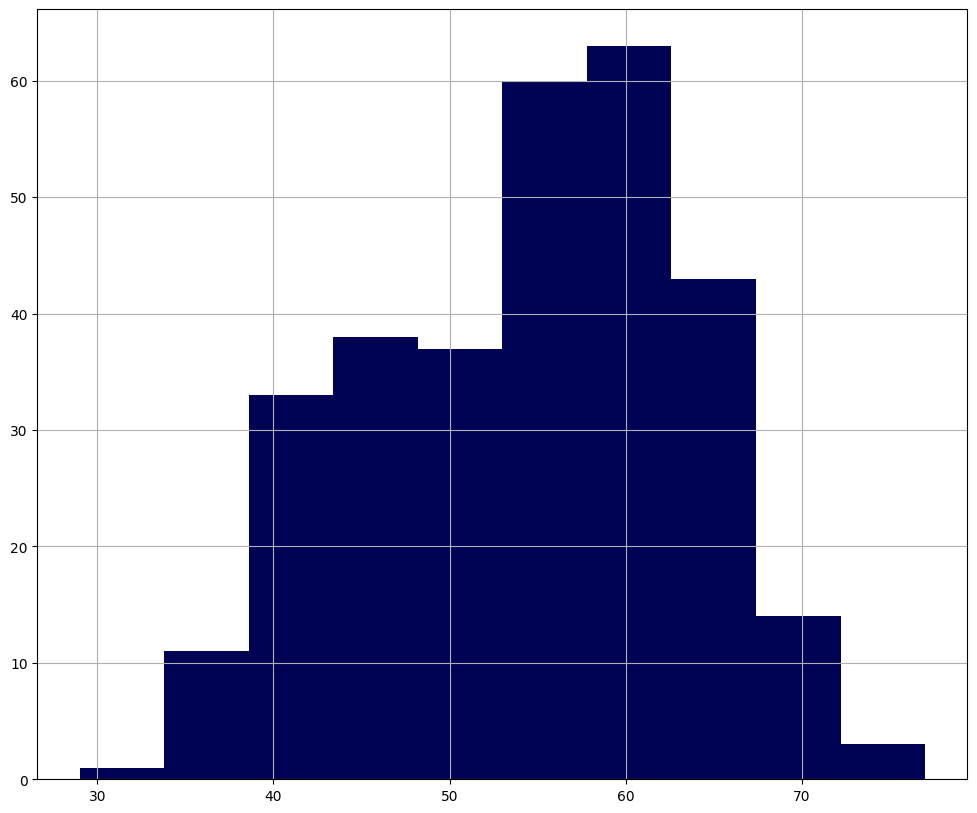

In [17]:
df_1 = df.copy()
features = 'age'
df_1[features].hist(figsize = (12,10),  color = '#000354');

Most data points follow an approximation of a normal distribution. Age is around 60.

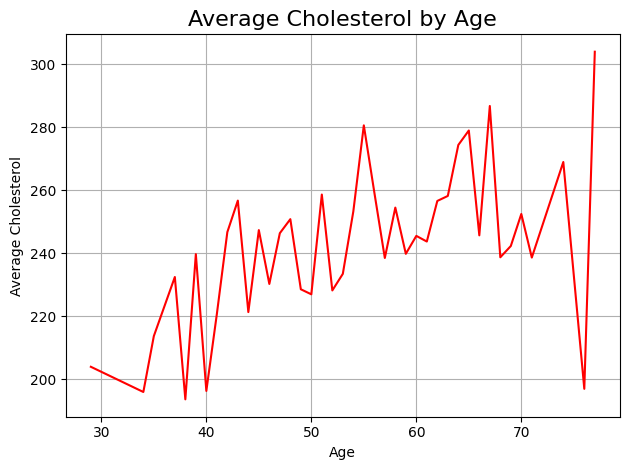

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_1 = df.copy()
# Group by age and calculate mean cholesterol
age_chol = df_1.groupby('age')['chol'].mean().reset_index()

# Plot
sns.lineplot(x = 'age', y = 'chol', data = age_chol, color='red')
plt.title("Average Cholesterol by Age", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Average Cholesterol")
plt.grid(True)
plt.tight_layout()
plt.show()

What is observed conforms to what was seen in the correlation matrix, where there's a positive correlation between cholesterol and age.

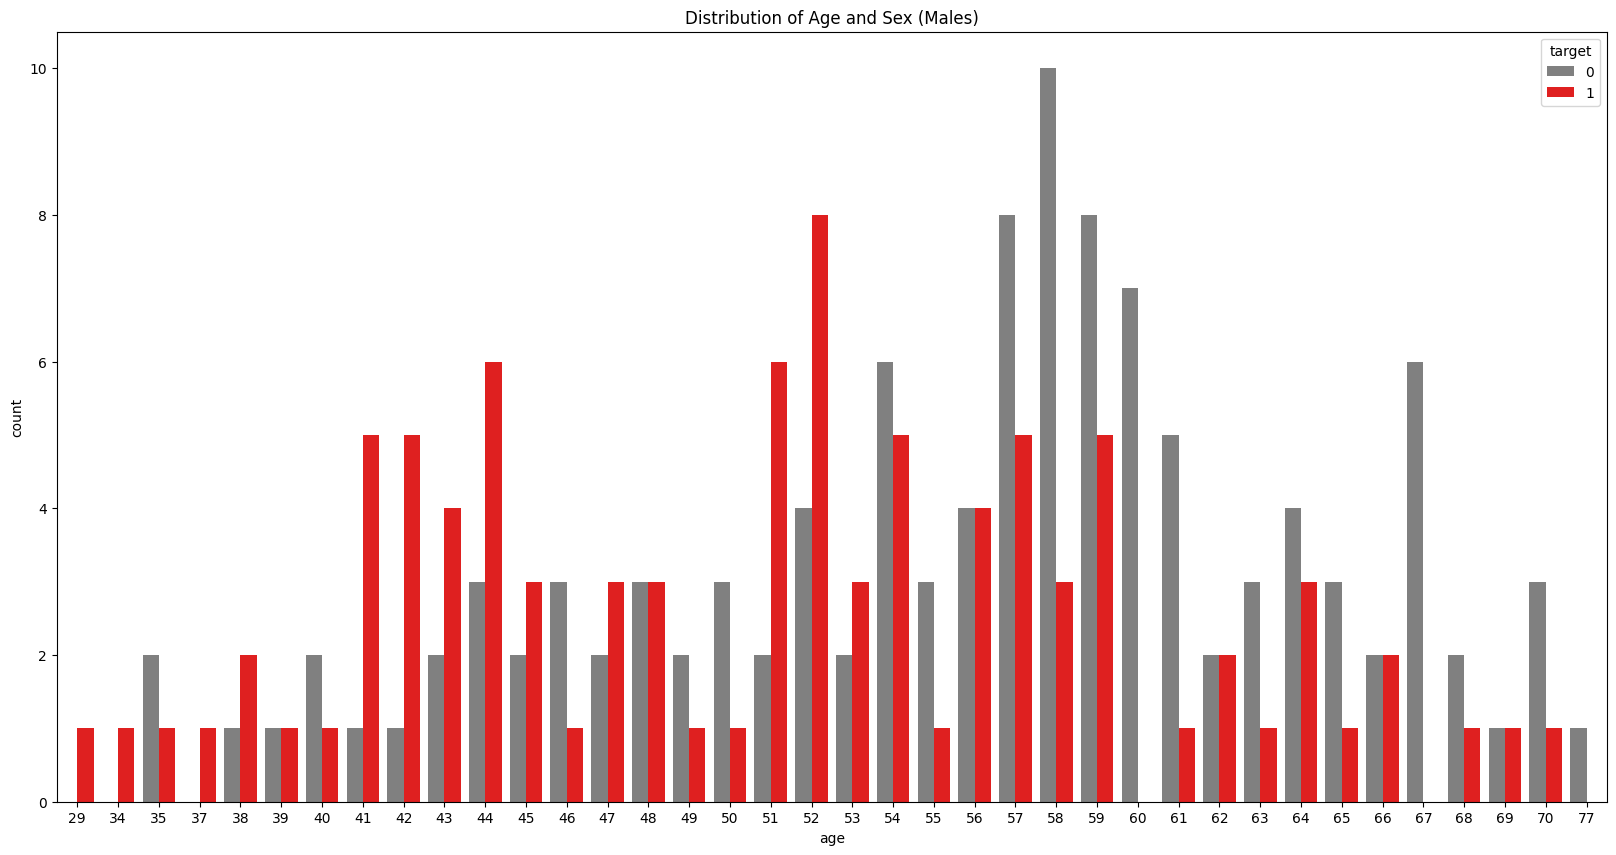

In [27]:
from matplotlib import rcParams
df_1 = df.copy()
custom_palette = {0: 'grey', 1: 'red'}
sns.countplot(x = 'age', data = df_1[df_1['sex'] == 1], palette = custom_palette, hue = 'target' )
rcParams['figure.figsize'] = 30,10
plt.title("Distribution of Age and Sex (Males)");

- High likelihood of heart disease in males above the age of 40 and 60.
- As individuals age, cholesterol levels tend to increase.This shift is caused by hormonal changes, reduced metabolic efficiency, and lifestyle factors such as diet and physical activity. These age-related changes in cholesterol contribute to a higher likelihood of developing heart-related diseases, making regular monitoring and lifestyle changes crucial for older individuals.

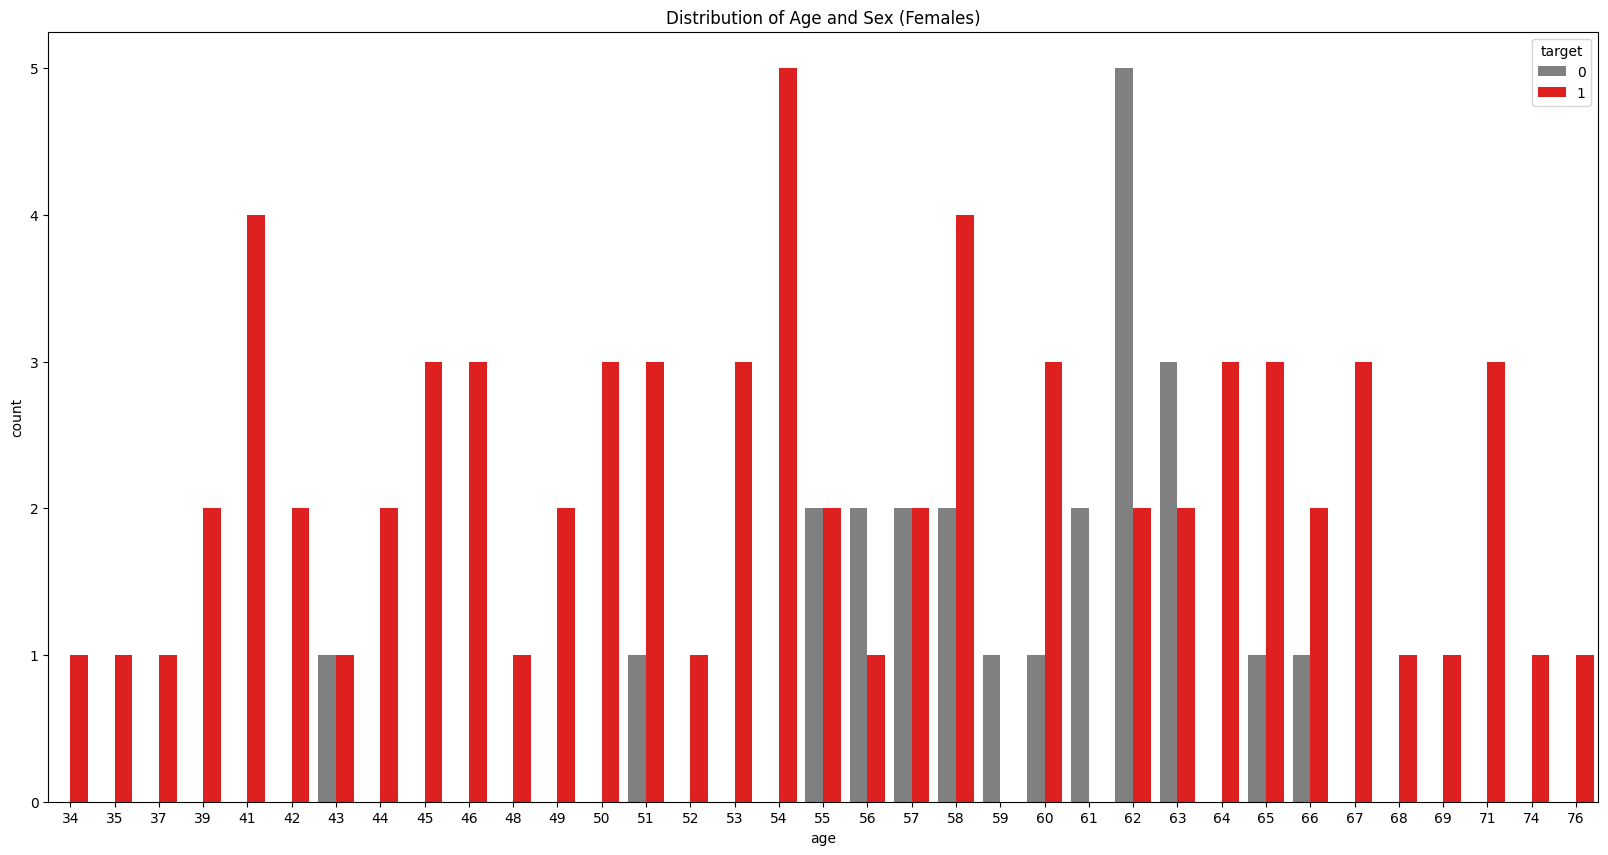

In [20]:
from matplotlib import rcParams
df_1 = df.copy()
custom_palette = {0: 'grey', 1: 'red'}
sns.countplot(x = 'age', data = df_1[df_1['sex'] == 0], palette = custom_palette, hue = 'target' )
rcParams['figure.figsize'] = 20,10
plt.title("Distribution of Age and Sex (Females)");

Trend is going up between charges and age. This shows a strong positive correlation between these two features. It is difficult to make conclusions with the skewness in females embedded in the data.

# **Model Building and Testing**

In [21]:
# splitting dataset into training and testing
df_data = df.copy()
X = df_data.drop(['target'], axis = 1)
Y = df_data['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size = 0.2, random_state = 42)

In [22]:
# initialise model
lr_model = LogisticRegression()

#train model
lr_model.fit(x_train, y_train)

LogisticRegression()

In [23]:
# Making predictions
y_pred_tr = lr_model.predict(x_train)
y_pred_te = lr_model.predict(x_test)

# **Model Evaluation**

**Classification Evaluation Metrics**

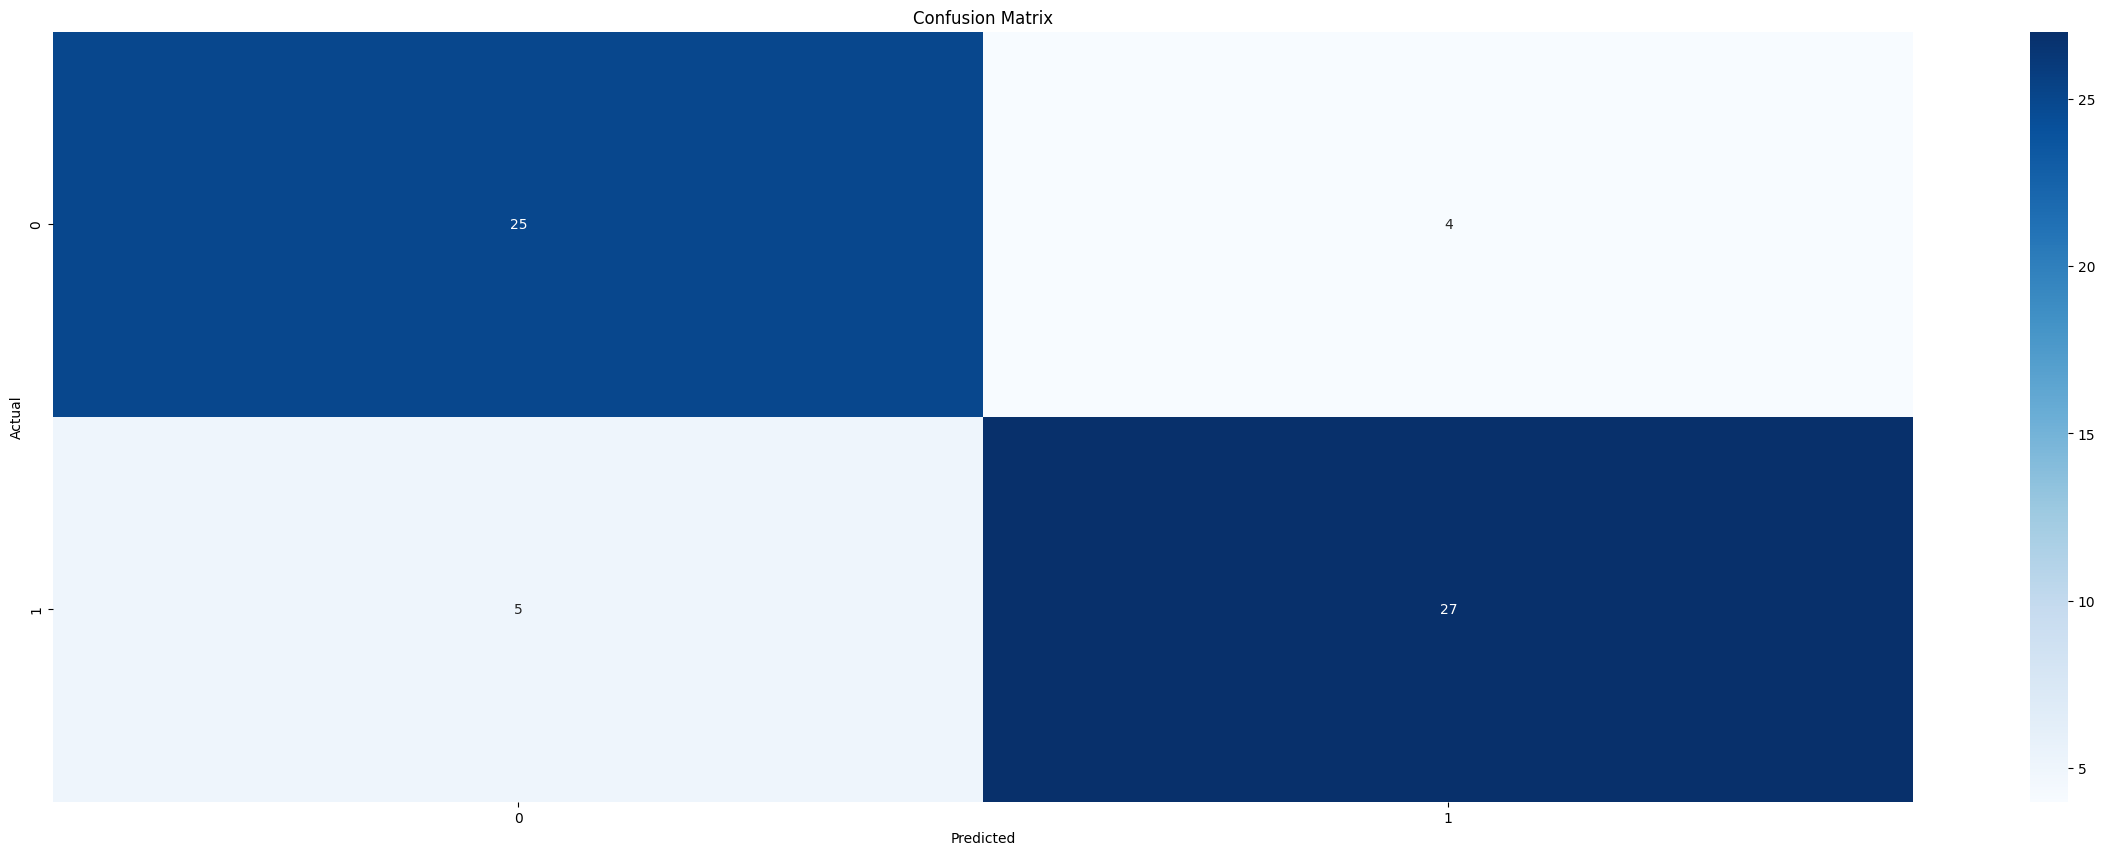

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
#Model evaluation
from sklearn.metrics import mean_squared_error

metrics = {
    'Metric': ['Accuracy', 'F-1 Score'],
    'Training': [round(accuracy_score(y_train, y_pred_tr),3), round(f1_score(y_train, y_pred_tr),3)],
    'Testing data': [round(accuracy_score(y_test, y_pred_te),3),round(f1_score(y_test, y_pred_te),3)
    ]
}
# Create the DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(metrics_df, headers = 'keys', tablefmt = 'pretty'))

+---+-----------+----------+--------------+
|   |  Metric   | Training | Testing data |
+---+-----------+----------+--------------+
| 0 | Accuracy  |  0.864   |    0.852     |
| 1 | F-1 Score |  0.881   |    0.857     |
+---+-----------+----------+--------------+
